## 환경 설정 및 라이브러리 임포트

In [1]:
import os
import re
import cv2
import uuid
import time
import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from dotenv import load_dotenv
from pathlib import Path

env_path = Path("../../../.env.development")
load_dotenv(dotenv_path=env_path)

SECRET_KEY = os.getenv("CLOVA_OCR_SECRET_KEY")
INVOKE_URL  = os.getenv("CLOVA_OCR_INVOKE_URL")

print(f"SECRET_KEY: {'설정됨' if SECRET_KEY else '없음'}")
print(f"INVOKE_URL: {'설정됨' if INVOKE_URL else '없음'}")

SECRET_KEY: 설정됨
INVOKE_URL: 설정됨


## 경로 설정

In [2]:
BASE_DIR   = "../../data/ocr/prescriptions"
INPUT_DIR  = os.path.join(BASE_DIR, "output_png")
AUG_DIR    = os.path.join(BASE_DIR, "output_aug")
RESULT_DIR = os.path.join(BASE_DIR, "output_ocr")
CSV_PATH   = os.path.join(BASE_DIR, "처방전_데이터.csv")
os.makedirs(RESULT_DIR, exist_ok=True)

df_gt = pd.read_csv(CSV_PATH, encoding="utf-8-sig")

print(f"원본: {INPUT_DIR}")
print(f"증강: {AUG_DIR}")
print(f"결과: {RESULT_DIR}")
print(f"정답 CSV: {len(df_gt)}개")

원본: ../../data/ocr/prescriptions\output_png
증강: ../../data/ocr/prescriptions\output_aug
결과: ../../data/ocr/prescriptions\output_ocr
정답 CSV: 500개


## Clova OCR API 함수

In [3]:
def call_clova_ocr(img_path):
    """Clova OCR API 호출 → 결과 JSON 반환"""
    with open(img_path, "rb") as f:
        img_data = f.read()

    ext = os.path.splitext(img_path)[1].lower().replace(".", "")
    if ext == "jpg":
        ext = "jpeg"

    payload = {
        "images": [{"format": ext, "name": "prescription"}],
        "requestId": str(uuid.uuid4()),
        "version": "V2",
        "timestamp": int(time.time() * 1000),
    }

    response = requests.post(
        INVOKE_URL,
        headers={"X-OCR-SECRET": SECRET_KEY},
        data={"message": json.dumps(payload)},
        files={"file": img_data},
    )

    if response.status_code != 200:
        print(f"에러: {response.status_code} {response.text}")
        return None

    return response.json()


def parse_clova_result(result):
    """Clova OCR 결과 → 텍스트 리스트 변환"""
    if not result:
        return []
    texts = []
    for image in result.get("images", []):
        for field in image.get("fields", []):
            texts.append({
                "text": field["inferText"],
                "confidence": field["inferConfidence"],
                "bbox": field["boundingPoly"]["vertices"],
            })
    return texts

print("API 함수 정의 완료")

API 함수 정의 완료


## 필드 추출 함수

In [36]:
def extract_fields(texts):
    """Clova OCR 텍스트 리스트 → 처방전 필드 딕셔너리"""
    text_list = [t["text"] for t in texts]

    fields = {
        "facility_code": None,
        "issue_info":    None,
        "facility_name": None,
        "patient_name":  None,
        "patient_ssn":   None,
        "disease_code":  None,
        "doctor_name":   None,
        "license_type":  None,
        "license_no":    None,
        "medications":   [],
        "med_usage":     None,
        "inject_in":     None,
        "inject_out":    None,
        "inject_info":   [],
        "pharmacy_note": None,
        "valid_period":  None,
    }

    skip_words = [
        "환자", "의사", "의료", "처방", "발급", "성명", "기관", "분류",
        "면허", "전화번호", "팩스번호", "주민등록번호", "요양기관기호", "연월일",
        "성", "명", "의원",
    ]

    dose_pattern   = re.compile(r"^\d+(\.\d+)?(정|캡슐|앰플|mg|mL|g|포|개|병)$")
    freq_pattern   = re.compile(r"^\d+회$")
    days_pattern   = re.compile(r"^\d+일$")
    med_pattern    = re.compile(r"(mg|캡슐|정)\d*$", re.IGNORECASE)
    inject_pattern = re.compile(r"^[\w가-힣]+주사$")

    skip_set = {"처방명세", "주사제", "조제기관", "조제약사", "조제량", "조제연월일",
                "내", "외", "조제,", "□원", "처방", "조제", "시", "참고", "사항",
                "본인부담", "구분기호", ")"}

    def get_dose_freq_days(start_idx, window=20):
        dose = freq = days = None
        for j in range(start_idx, min(start_idx + window, len(text_list))):
            nxt = text_list[j]
            if any(kw in nxt for kw in skip_set):
                continue
            if dose is None and dose_pattern.match(nxt):
                dose = nxt
            elif freq is None and freq_pattern.match(nxt):
                freq = nxt
            elif days is None and days_pattern.match(nxt):
                days = nxt
            if dose and freq and days:
                break
        return dose, freq, days

    for i, text in enumerate(text_list):

        # 요양기관기호
        if "요양기관기호" in text:
            match = re.search(r'\d{8}', text)
            if match:
                fields["facility_code"] = match.group()
            elif i+1 < len(text_list):
                fields["facility_code"] = text_list[i+1]

        # 발급일자 - 연월일 + 제 N 호 이어붙임
        if re.search(r'\d{4}년', text) and fields["issue_info"] is None:
            parts = [text]
            for j in range(i+1, min(i+8, len(text_list))):
                nxt = text_list[j]
                if re.search(r'\d{1,2}월|\d{1,2}일', nxt):
                    parts.append(nxt)
                elif nxt in ("제", "호") or re.match(r'^\d+$', nxt):
                    parts.append(nxt)
                elif nxt == "-":
                    parts.append(nxt)
                else:
                    if re.search(r'\d{1,2}월|\d{1,2}일|제|\d+|호', nxt):
                        parts.append(nxt)
                    else:
                        break
            fields["issue_info"] = " ".join(parts)

        # 병원명
        if text == "명칭" and i+1 < len(text_list):
            candidate = text_list[i+1]
            if re.search(r"[가-힣]", candidate) and any(kw in candidate for kw in ["의원", "병원", "의학", "클리닉"]):
                fields["facility_name"] = candidate

        # 환자명 + 주민등록번호
        if "주민등록번호" in text:
            for j in range(i-1, max(i-10, -1), -1):
                candidate = text_list[j]
                if re.match(r"^[가-힣]{2,4}$", candidate) and candidate not in skip_words:
                    fields["patient_name"] = candidate
                    break
            if i+1 < len(text_list):
                fields["patient_ssn"] = text_list[i+1]

        # 질병코드
        if re.match(r"^[A-Z]\d{2}", text):
            fields["disease_code"] = text

        # 의사명
        if text == "성명" and i+1 < len(text_list):
            candidate = text_list[i+1]
            if re.match(r"^[가-힣]{2,4}$", candidate) and candidate not in skip_words:
                fields["doctor_name"] = candidate

        # 면허종류 + 면허번호 (OCR이 면허번호→면허종류 순으로 인식)
        if text == "면허종류" and i+1 < len(text_list):
            fields["license_type"] = text_list[i+1]
        if text == "면허번호":
            parts = []
            for j in range(i+3, min(i+8, len(text_list))):
                nxt = text_list[j]
                if re.search(r'제|\d+|호', nxt):
                    parts.append(nxt)
                elif nxt in ("면허종류", "면허번호"):
                    break
                else:
                    if parts:
                        break
            if parts:
                fields["license_no"] = " ".join(parts)

        # 약 이름 + dose/freq/days
        if med_pattern.search(text) and re.match(r"^[가-힣]", text):
            if text not in [m["name"] for m in fields["medications"]]:
                dose, freq, days = get_dose_freq_days(i+1)
                fields["medications"].append({"name": text, "dose": dose, "freq": freq, "days": days})

        # 복약방법
        if any(kw in text for kw in ["매식후", "매식전", "매식간", "취침전", "아침식후", "아침저녁"]):
            fields["med_usage"] = text

        # 원내/원외 - 처방명세 텍스트에서 체크 위치로 판단
        if "처방명세" in text:
            check_pos = -1
            for ch in ("☑", "✓", "✔"):
                pos = text.find(ch)
                if pos != -1:
                    check_pos = pos
                    break
            # 다음 텍스트가 '내'면 원내 체크
            next_text = text_list[i+1] if i+1 < len(text_list) else ""
            if check_pos != -1:
                if next_text.strip() in ("내", "내 조제"):
                    fields["inject_in"]  = "[✓]원 내 조제"
                    fields["inject_out"] = "[ ]원 외 처방"
                else:
                    fields["inject_in"]  = "[ ]원 내 조제"
                    fields["inject_out"] = "[✓]원 외 처방"
            else:
                fields["inject_in"]  = "[ ]원 내 조제"
                fields["inject_out"] = "[ ]원 외 처방"

        # 주사제 + dose/freq/days
        if inject_pattern.match(text) and "주사제" not in text and "처방명세" not in text:
            dose, freq, days = get_dose_freq_days(i+1)
            fields["inject_info"].append({"name": text, "dose": dose, "freq": freq, "days": days})

        # 약국 참고사항
        if any(kw in text for kw in ["냉장보관", "빛을 피해"]):
            fields["pharmacy_note"] = text

        # 유효기간
        if "발급일부터" in text:
            parts = [text]
            for j in range(i+1, min(i+8, len(text_list))):
                nxt = text_list[j]
                if re.search(r'\d+|일간|\(|\)', nxt):
                    parts.append(nxt)
                else:
                    break
            fields["valid_period"] = " ".join(parts)

    return fields

print("필드 추출 함수 정의 완료")

필드 추출 함수 정의 완료


## 평가 함수

In [13]:
def normalize(text):
    """비교를 위한 텍스트 정규화"""
    if not text or pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"\s+", "", text)
    text = re.sub(r"[^\w가-힣]", "", text)
    return text.lower()


def evaluate(fields, file_index):
    """추출된 필드를 CSV 정답과 비교해 정확도 반환"""
    gt = df_gt.iloc[file_index - 1]

    meds = fields.get("medications", [])
    injs = fields.get("inject_info", [])

    comparisons = {
        "facility_code": (fields.get("facility_code"),  str(gt["facility_code"])),
        "facility_name": (fields.get("facility_name"),  str(gt["facility_name"])),
        "patient_name":  (fields.get("patient_name"),   str(gt["patient_name"])),
        "patient_ssn":   (fields.get("patient_ssn"),    str(gt["patient_ssn"])),
        "disease_code":  (fields.get("disease_code"),   str(gt["disease_code"])),
        "doctor_name":   (fields.get("doctor_name"),    str(gt["doctor_name"])),
        "med_name_1":    (meds[0]["name"] if len(meds) > 0 else None, str(gt["med_name_1"])),
        "med_name_2":    (meds[1]["name"] if len(meds) > 1 else None, str(gt["med_name_2"])),
        "med_name_3":    (meds[2]["name"] if len(meds) > 2 else None, str(gt["med_name_3"])),
        "med_name_4":    (meds[3]["name"] if len(meds) > 3 else None, str(gt["med_name_4"])),
        "med_name_5":    (meds[4]["name"] if len(meds) > 4 else None, str(gt["med_name_5"])),
        "med_name_6":    (meds[5]["name"] if len(meds) > 5 else None, str(gt["med_name_6"])),
        "med_name_7":    (meds[6]["name"] if len(meds) > 6 else None, str(gt["med_name_7"])),
        "inject_name_1": (injs[0]["name"] if len(injs) > 0 else None, str(gt["inject_name_1"])),
        "inject_name_2": (injs[1]["name"] if len(injs) > 1 else None, str(gt["inject_name_2"])),
        "inject_name_3": (injs[2]["name"] if len(injs) > 2 else None, str(gt["inject_name_3"])),
    }

    results = []
    for field, (pred, gt_val) in comparisons.items():
        match = normalize(pred) == normalize(gt_val)
        results.append({"field": field, "pred": pred, "gt": gt_val, "match": match})

    df_eval = pd.DataFrame(results)
    correct = df_eval["match"].sum()
    total = len(df_eval)
    print(f"정확도: {correct}/{total} ({correct/total*100:.1f}%)\n")
    print(df_eval.to_string(index=False))
    return df_eval

print("평가 함수 정의 완료")

평가 함수 정의 완료


## 단건 테스트

> 주석 해제 후 실행하세요.

=== 추출 결과 ===
[facility_code]
  67013826
[issue_info]
  2024년 11월 03일 - 제 2932 호
[facility_name]
  부천중앙의원
[patient_name]
  백현준
[patient_ssn]
  900713-2210722
[disease_code]
  J31.0
[doctor_name]
  문유진
[license_type]
  한의사
[license_no]
  제 90439 호
[medications]
  {'name': '세티리진정10mg', 'dose': '1정', 'freq': '1회', 'days': '3일'}
  {'name': '오메프라졸캡슐20mg', 'dose': '1캡슐', 'freq': '1회', 'days': '3일'}
  {'name': '로사르탄정50mg', 'dose': '1정', 'freq': '1회', 'days': '3일'}
  {'name': '트리메부틴정100mg', 'dose': '1정', 'freq': '3회', 'days': '3일'}
  {'name': '레보플록사신정500mg', 'dose': '1정', 'freq': '3회', 'days': '3일'}
  {'name': '이부프로펜정400mg', 'dose': '1정', 'freq': '3회', 'days': '3일'}
  {'name': '메트포르민정1000mg', 'dose': '1정', 'freq': '3회', 'days': '3일'}
[med_usage]
  매식후
[inject_in]
  [✓]원 내 조제
[inject_out]
  [ ]원 외 처방
[inject_info]
  {'name': '온단세트론주사', 'dose': '1앰플', 'freq': '1회', 'days': '1일'}
  {'name': '리도카인주사', 'dose': '1앰플', 'freq': '1회', 'days': '1일'}
  {'name': '비타민C주사', 'dose': '1앰플', 'freq': '1회', 'day

C:\Users\Administrator\AppData\Local\Temp\ipykernel_44888\2183740148.py:54: UserWarning: Glyph 9745 (\N{BALLOT BOX WITH CHECK}) missing from font(s) NanumGothic.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_44888\2183740148.py:55: UserWarning: Glyph 9745 (\N{BALLOT BOX WITH CHECK}) missing from font(s) NanumGothic.
  plt.savefig(os.path.join(RESULT_DIR, f"{test_fname.replace('.png', '')}_clova_viz.png"), dpi=150, bbox_inches="tight")
D:\AH_03_06\ml\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9745 (\N{BALLOT BOX WITH CHECK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


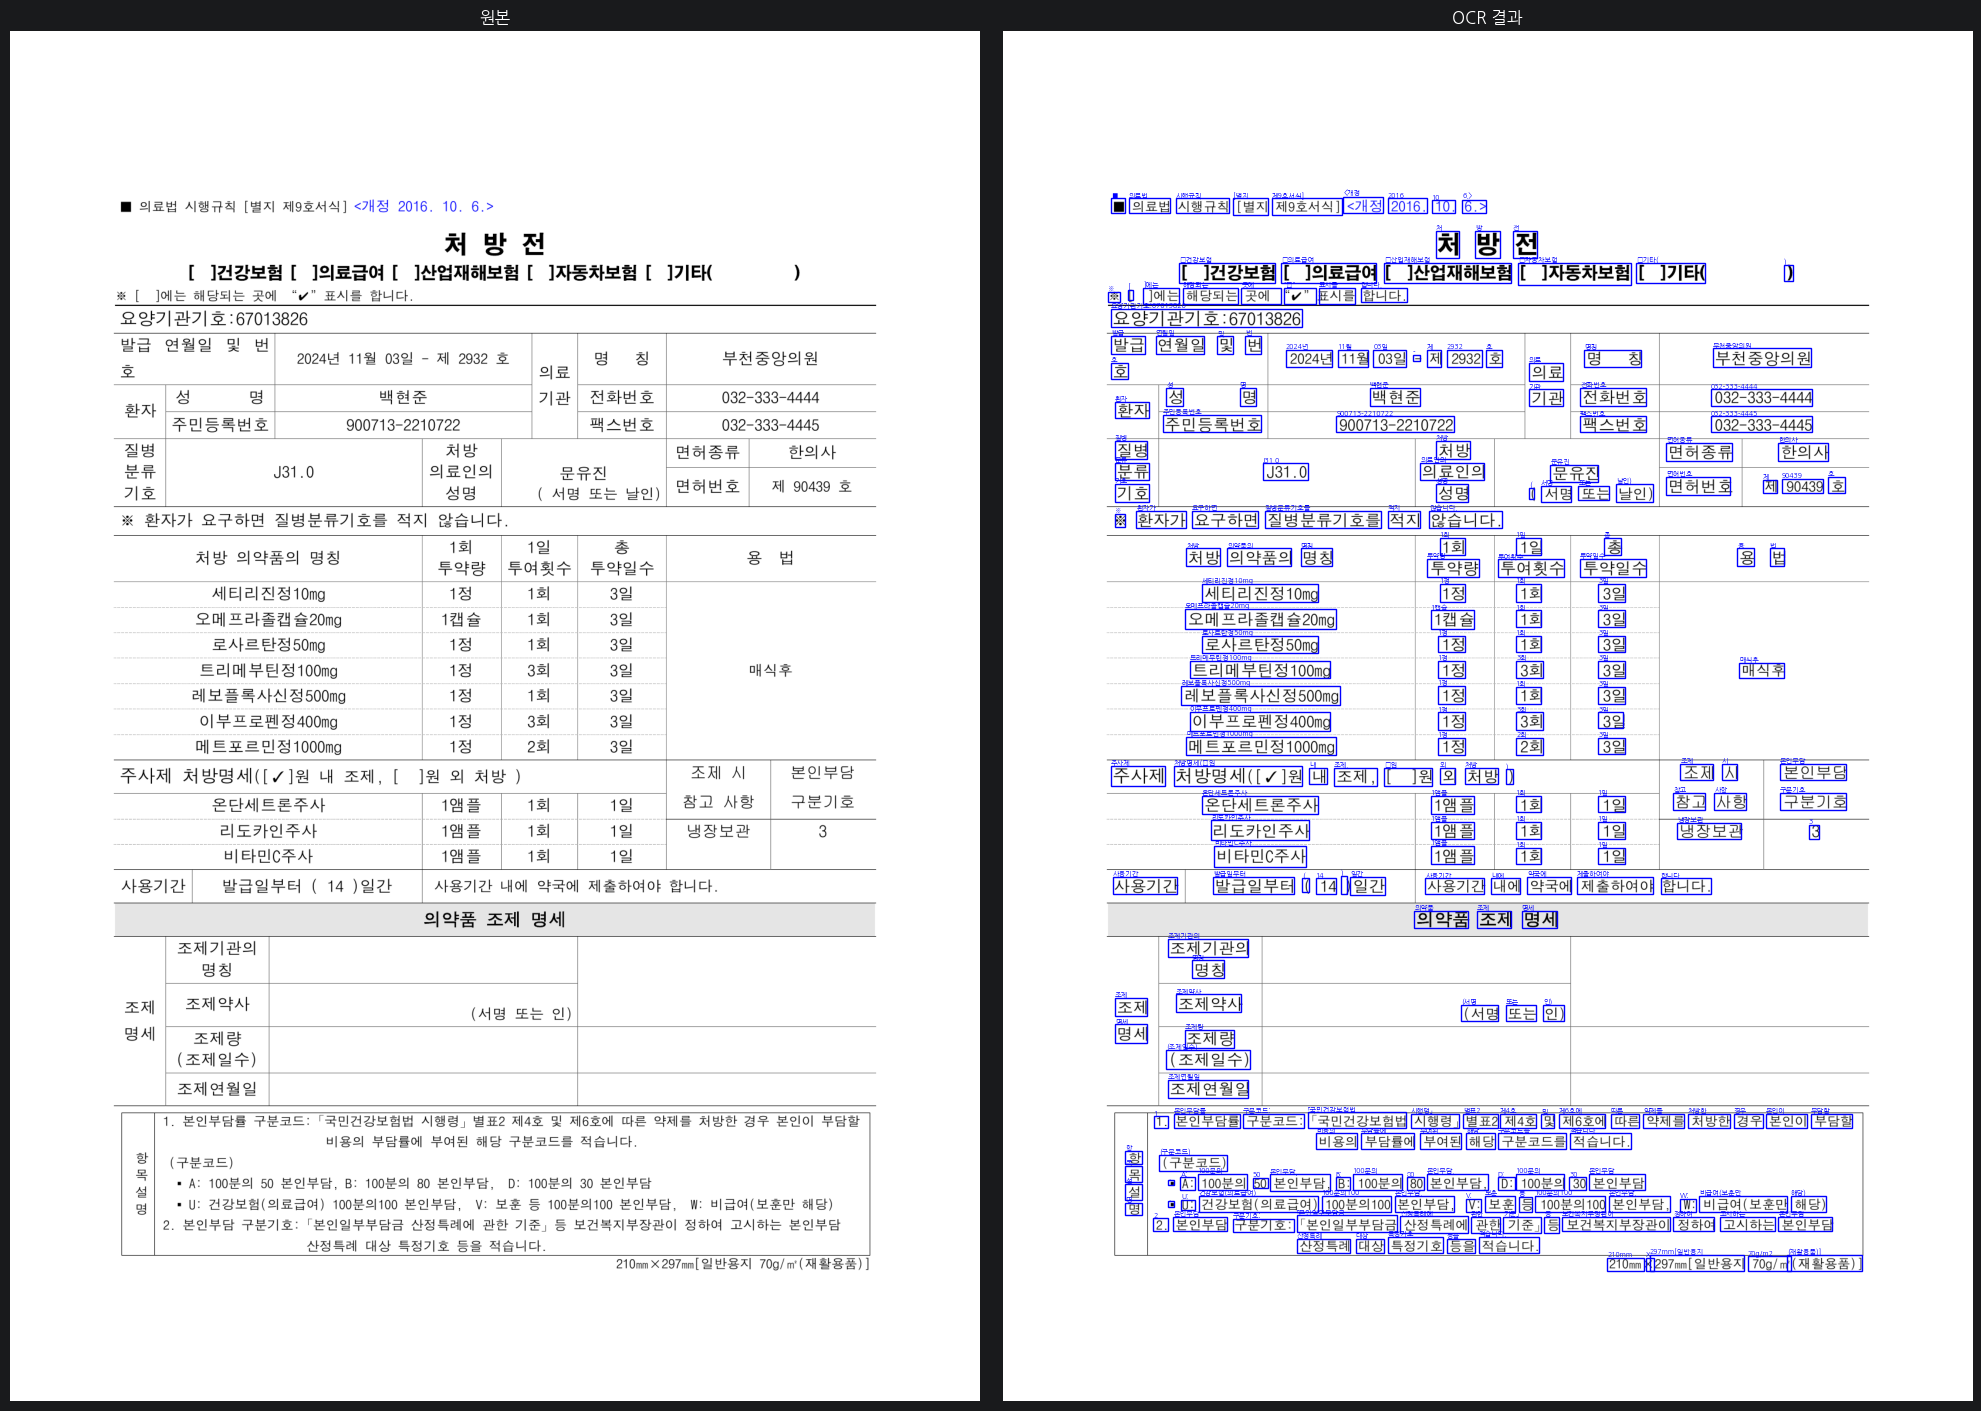

In [37]:
import re
import koreanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

test_fname = "처방전_0062.png"
file_index = int(re.search(r'\d+', test_fname).group())

test_path = os.path.join(INPUT_DIR, test_fname)
img = cv2.imdecode(np.fromfile(test_path, dtype=np.uint8), cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

result = call_clova_ocr(test_path)
texts = parse_clova_result(result)
text_list = [t["text"] for t in texts]

fields = extract_fields(texts)

# 필드 출력
print("=== 추출 결과 ===")
for k, v in fields.items():
    if v:
        print(f"[{k}]")
        if isinstance(v, list):
            for item in v: print(f"  {item}")
        else:
            print(f"  {v}")

# 조제/처방 관련 텍스트 확인
print("\n=== 조제/처방 관련 텍스트 ===")
for t in text_list:
    if any(kw in t for kw in ["조제", "처방", "원내", "원외"]):
        print(repr(t))

for i, t in enumerate(text_list):
    if "온단세트론" in t:
        for j in range(i+1, min(i+20, len(text_list))):
            print(f"  [{j}] {repr(text_list[j])}")

# 정확도 평가
evaluate(fields, file_index)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 14))
axes[0].imshow(img_rgb); axes[0].set_title("원본"); axes[0].axis("off")
axes[1].imshow(img_rgb); axes[1].set_title("OCR 결과"); axes[1].axis("off")
for t in texts:
    verts = t["bbox"]
    xs = [v["x"] for v in verts]; ys = [v["y"] for v in verts]
    x_min, y_min = min(xs), min(ys)
    w, h = max(xs)-x_min, max(ys)-y_min
    axes[1].add_patch(patches.Rectangle((x_min, y_min), w, h, linewidth=1, edgecolor="blue", facecolor="none"))
    axes[1].text(x_min, y_min-2, t["text"], fontsize=5, color="blue")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f"{test_fname.replace('.png', '')}_clova_viz.png"), dpi=150, bbox_inches="tight")
plt.show()

## 전체 배치 평가

> 주석 해제 후 실행하세요. Clova API 호출 비용 발생.

In [45]:
png_files = sorted([f for f in os.listdir(INPUT_DIR) if f.endswith(".png") and "_aug" not in f])[5:15]
print(f"총 {len(png_files)}개 파일")

all_results = []
for fname in png_files:
    file_index = int(re.search(r'\d+', fname).group())
    img_path = os.path.join(INPUT_DIR, fname)
    result = call_clova_ocr(img_path)
    texts = parse_clova_result(result)
    fields = extract_fields(texts)

    gt = df_gt.iloc[file_index - 1]

    row = {"파일명": fname}
    for field in ["facility_code", "facility_name", "patient_name", "patient_ssn", "disease_code", "doctor_name"]:
        pred = fields.get(field)
        row[field] = normalize(pred) == normalize(str(gt[field]))
    for k in range(1, 8):
        pred = fields["medications"][k-1]["name"] if len(fields["medications"]) >= k else None
        gt_val = gt[f"med_name_{k}"]
        row[f"med_name_{k}"] = normalize(pred) == normalize(str(gt_val) if not pd.isna(gt_val) else "")
    for k in range(1, 4):
        pred = fields["inject_info"][k-1]["name"] if len(fields["inject_info"]) >= k else None
        gt_val = gt[f"inject_name_{k}"]
        row[f"inject_name_{k}"] = normalize(pred) == normalize(str(gt_val) if not pd.isna(gt_val) else "")

    all_results.append(row)
    print(f"완료: {fname}")

df_batch = pd.DataFrame(all_results)
csv_out = os.path.join(RESULT_DIR, "batch_eval_results.csv")
df_batch.to_csv(csv_out, index=False, encoding="utf-8-sig")

bool_cols = [c for c in df_batch.columns if c != "파일명"]
acc = df_batch[bool_cols].mean().mean() * 100
print(f"\n전체 평균 정확도: {acc:.1f}%")
print(f"결과 저장 → {csv_out}")

총 10개 파일
완료: 처방전_0006.png
완료: 처방전_0007.png
완료: 처방전_0008.png
완료: 처방전_0009.png
완료: 처방전_0010.png
완료: 처방전_0011.png
완료: 처방전_0012.png
완료: 처방전_0013.png
완료: 처방전_0014.png
완료: 처방전_0015.png

전체 평균 정확도: 97.5%
결과 저장 → ../../data/ocr/prescriptions\output_ocr\batch_eval_results.csv
